# Notebook 05: Statistical Diagnostics & Feature Quality Audit

## Project: Enterprise Credit Risk Modelling & Independent Model Validation (SR 11-7)

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

root_path = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = root_path / "src"
for p in [str(root_path), str(src_path)]:
    if p not in sys.path:
        sys.path.insert(0, p)

sns.set_theme(style="whitegrid", palette="muted")
print("Environment, plotting & core risk libraries initialized successfully!")

Environment, plotting & core risk libraries initialized successfully!


In [2]:
data_file = root_path / "data" / "processed" / "accepted_2007_to_2018Q4_feature_engineered.csv.gz"
if data_file.is_file():
    df = pd.read_csv(data_file, nrows=50000, low_memory=False)
    bad = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "Late (31-120 days)"]
    good = ["Fully Paid", "Does not meet the credit policy. Status:Fully Paid"]
    df["target"] = np.nan
    df.loc[df["loan_status"].isin(bad), "target"] = 1.0
    df.loc[df["loan_status"].isin(good), "target"] = 0.0
    df = df.dropna(subset=["target"]).copy()
    df["target"] = df["target"].astype(int)
else:
    df = mock_df.copy()

print(f"Dataset Loaded: {len(df):,} loans | Default Rate: {df['target'].mean():.4%}")

Dataset Loaded: 44,252 loans | Default Rate: 20.9572%


In [3]:
from validation.statistical_tests import calculate_descriptive_stats
num_feats = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low"]
desc_table = calculate_descriptive_stats(df, num_feats)
desc_table

,feature,count,mean,median,mode,variance,std_dev,coef_variation,min,max,range,q1,q3,iqr,skewness,kurtosis
0,loan_amnt,44252,14351.6683,12000.00,10000.00,7.438297e+07,8624.5563,0.6009,1000.00,35000.00,34000.00,7800.00,20000.00,12200.00,0.7103,-0.2655
1,int_rate,44252,12.0094,11.49,9.17,1.757860e+01,4.1927,0.3491,5.32,28.99,23.67,9.17,14.48,5.31,0.7125,0.4987
2,installment,44252,429.1963,369.57,318.79,6.487690e+04,254.7094,0.5935,14.77,1354.66,1339.89,244.25,572.19,327.94,0.9330,0.4924
3,annual_inc,44252,78499.8279,65000.00,60000.00,1.044444e+10,102198.0295,1.3019,0.00,9000000.00,9000000.00,47000.00,94000.00,47000.00,53.4994,4129.7444
4,dti,44251,19.0941,18.54,15.45,9.820130e+01,9.9097,0.5190,0.00,999.00,999.00,12.43,25.32,12.89,22.0685,2160.1592
5,fico_range_low,44252,694.2956,685.00,660.00,9.704796e+02,31.1525,0.0449,660.00,845.00,185.00,670.00,710.00,40.00,1.3630,1.9946


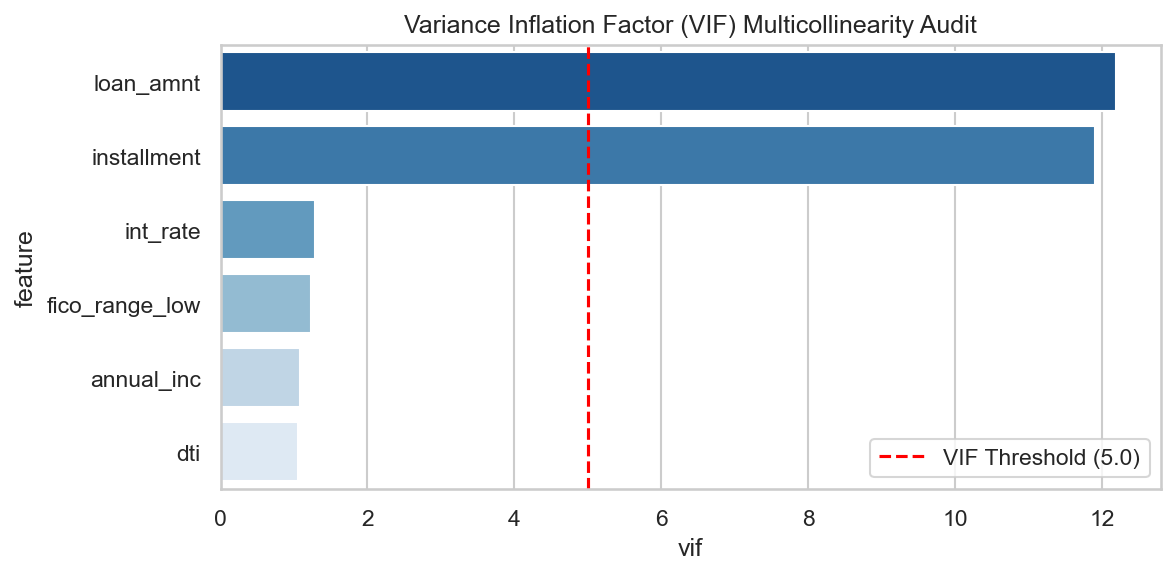

In [4]:
from validation.econometrics import calculate_vif_and_tolerance
vif_df = calculate_vif_and_tolerance(df, num_feats)
plt.figure(figsize=(8, 4))
sns.barplot(data=vif_df, x="vif", y="feature", palette="Blues_r")
plt.axvline(x=5.0, color="red", linestyle="--", label="VIF Threshold (5.0)")
plt.title("Variance Inflation Factor (VIF) Multicollinearity Audit")
plt.legend()
plt.tight_layout()
plt.show()